# 扩展分类：SVM、KNN、LightGBM

在威斯康星乳腺癌数据集上使用 **SVC**、**KNeighborsClassifier**、**LGBMClassifier**；报告 **准确率** 并绘制 **混淆矩阵**。


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from lightgbm import LGBMClassifier

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 1. 数据加载


In [5]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
cancer_df["TARGET"] = cancer.target

print("数据集形状：", cancer_df.shape)
print("缺失值总数：", cancer_df.isnull().sum().sum())
print("肿瘤类型分布：\n", cancer_df["TARGET"].value_counts().rename({0: "恶性", 1: "良性"}))

X_c = cancer_df.drop("TARGET", axis=1)
y_c = cancer_df["TARGET"]


数据集形状： (569, 31)
缺失值总数： 0
肿瘤类型分布：
 TARGET
良性    357
恶性    212
Name: count, dtype: int64


## 2. 预处理与划分


In [6]:
scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c_scaled, y_c, test_size=0.3, random_state=42
)
print("训练集样本数：", X_c_train.shape[0])
print("测试集样本数：", X_c_test.shape[0])


训练集样本数： 398
测试集样本数： 171


## 3. 模型训练（SVC / KNN / LightGBM）


In [7]:
svc = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc.fit(X_c_train, y_c_train)
print("SVC 训练完成")

knn_clf = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_clf.fit(X_c_train, y_c_train)
print("KNN 分类训练完成")

lgbm_clf = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    verbose=-1,
)
lgbm_clf.fit(X_c_train, y_c_train)
print("LightGBM 分类训练完成")


SVC 训练完成
KNN 分类训练完成
LightGBM 分类训练完成


## 4. 评估：准确率与混淆矩阵



SVC 准确率：0.9708

KNN 准确率：0.9591

LightGBM 准确率：0.9532


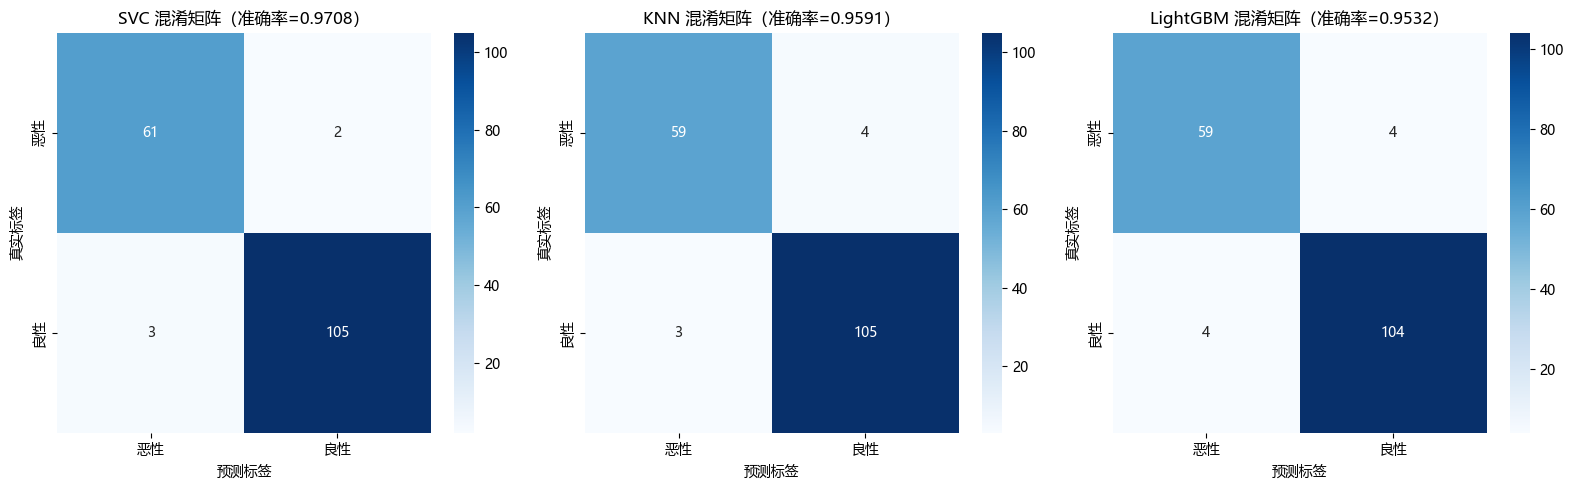

混淆矩阵：行=真实，列=预测；对角线为分类正确。


In [8]:
labels = ["恶性", "良性"]

def report(model, name: str):
    y_pred = model.predict(X_c_test)
    acc = accuracy_score(y_c_test, y_pred)
    print(f"\n{name} 准确率：{acc:.4f}")
    return y_pred, acc

pred_svc, acc_svc = report(svc, "SVC")
pred_knn, acc_knn = report(knn_clf, "KNN")
pred_lgbm, acc_lgbm = report(lgbm_clf, "LightGBM")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, y_pred, acc) in zip(
    axes,
    [
        ("SVC", pred_svc, acc_svc),
        ("KNN", pred_knn, acc_knn),
        ("LightGBM", pred_lgbm, acc_lgbm),
    ],
):
    cm = confusion_matrix(y_c_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("预测标签")
    ax.set_ylabel("真实标签")
    ax.set_title(f"{name} 混淆矩阵（准确率={acc:.4f}）")
plt.tight_layout()
plt.show()

print("混淆矩阵：行=真实，列=预测；对角线为分类正确。")
